# Binary Class Penguin Logistic Regression (NumPy)

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from matplotlib import cm

In [2]:
# read the variables: class label and features

def string2float(item):
    return float(item) if item != '' else None

def read_strings(filename, col):
    with open(filename) as f:
        lines = f.readlines()
    values = [line.strip().split(',')[col] for line in lines[1:]]
    return values

def read_floats(filename, col):
    with open(filename) as f:
        lines = f.readlines()
    values = [string2float(line.strip().split(',')[col]) for line in lines[1:]]
    return values

def read_data_and_label(filename):
    x1 = np.array(read_floats(filename, col=4))  # flipper length
    x2 = np.array(read_floats(filename, col=5))  # body mass
    y = np.array(read_strings(filename, col=0))  # species

    y = [s == 'Gentoo' for s in y]
    y = np.array(y).astype(float)

    idx = (x1 != None) & (x2 != None) & (y != None)
    x1 = x1[idx]
    x2 = x2[idx]
    y = y[idx]

    X = np.stack((x1, x2), axis=1).astype(float)
    y = y.reshape((y.size, 1)).astype(float)

    return X, y

In [3]:
def min_max_normalize(X, min_val=None, max_val=None):
    X = np.array(X)
    if min_val is None:
        min_val = np.min(X, axis=0, keepdims=True)
    if max_val is None:
        max_val = np.max(X, axis=0, keepdims=True)
    range_val = max_val - min_val
    range_val = np.where(range_val == 0, 1, range_val)
    X_norm = (X - min_val) / range_val
    return X_norm, min_val, max_val

In [4]:
def z_score_normalize(X, mean=None, std=None):
    if mean is None:
        mean = np.mean(X, axis=0)
    if std is None:
        std = np.std(X, axis=0)
    std = np.where(std == 0, 1, std)
    X_norm = (X - mean) / std
    return X_norm, mean, std

In [5]:
def print_formatted_vector(vec):
    s = ' '.join(f"{x:.4f}" for x in vec)
    print(s)

In [6]:
class LogisticRegression:
    def __init__(self, in_dim, out_dim, reg=None, alpha=0.):
        rng = np.random.default_rng(seed=0)
        self.weight = rng.normal(loc=0, scale=1, size=(in_dim, out_dim))
        self.bias = rng.normal(loc=0, scale=1, size=out_dim)
        self.reg = reg
        self.alpha = alpha

    def sigmoid(self, x):
        x = np.clip(x, -500, 500)
        return 1 / (1 + np.exp(-x))

    def forward(self, x):
        x = np.dot(x, self.weight) + self.bias
        x = self.sigmoid(x)
        return x
    
    def compute_reg_term(self):
        if self.reg == 'l1norm':
            reg_term = self.alpha * np.abs(self.weight)
        elif self.reg == 'l2norm':
            reg_term = self.alpha * (self.weight ** 2)
        else:
            reg_term = np.zeros(self.weight.shape)
        return reg_term

    def compute_loss(self, y_true, y_prob):
        m = len(y_true)
        epsilon = 1e-15
        y_prob = np.clip(y_prob, epsilon, 1 - epsilon) # avoid log(0)
        loss = -1/m * np.sum(y_true * np.log(y_prob) + (1 - y_true) * np.log(1 - y_prob))
        penalty = np.sum(self.compute_reg_term())
        return loss + penalty

    def compute_gradient(self, x, y_true, y_prob):
        m = len(y_true)
        dw = (1/m) * np.dot(x.T, (y_prob - y_true))
        dw += self.compute_reg_term()
        db = (1/m) * np.sum(y_prob - y_true)
        return dw, db

    def step_update(self, dw, db, learning_rate=0.01):
        self.weight -= learning_rate * dw
        self.bias -= learning_rate * db

In [8]:
# training data

filename = 'data/palmer-penguins/palmer-penguins-train.txt'
X, y = read_data_and_label(filename)

X, X_mean, X_std = z_score_normalize(X)

FileNotFoundError: [Errno 2] No such file or directory: 'data/palmer-penguins/palmer-penguins-train.txt'

In [8]:
# test data

filename = 'data/palmer-penguins/palmer-penguins-test.txt'
Xs, ys = read_data_and_label(filename)

Xs, _, _ = z_score_normalize(Xs, X_mean, X_std)

In [9]:
# init training model

model = LogisticRegression(in_dim=X.shape[1], out_dim=1, reg=None, alpha=0.)
# model = LogisticRegression(in_dim=X.shape[1], out_dim=1, reg='l1norm', alpha=1)
# model = LogisticRegression(in_dim=X.shape[1], out_dim=1, reg='l2norm', alpha=1)

print(model.weight)
print(model.bias)

[[ 0.12573022]
 [-0.13210486]]
[0.64042265]


In [10]:
# training and test

trn_losses = []
tst_losses = []
grads = []

learning_rate = 0.1

for epoch in range(1000):
    y_prob = model.forward(X)

    dw, db = model.compute_gradient(X, y, y_prob)
    grads.append(np.linalg.norm(dw))

    model.step_update(dw, db, learning_rate)

    y_prob = model.forward(X)
    trn_loss = model.compute_loss(y, y_prob)
    trn_losses.append(trn_loss)
    
    ys_prob = model.forward(Xs)
    tst_loss = model.compute_loss(ys, ys_prob)
    tst_losses.append(tst_loss)

    ys_corr = (ys >= 1) == (ys_prob >= 0.5)
    tst_acc = np.mean(ys_corr)
    
    if (epoch + 1) % 100 == 0:
        print('epoch {}: trn loss {:.4f}, tst loss {:.4f}, tst accuracy {:.4f}'.format(epoch + 1, trn_loss, tst_loss, tst_acc))
        print_formatted_vector(y[::20].flatten())
        print_formatted_vector(y_prob[::20].flatten())

epoch 100: trn loss 0.1361, tst loss 0.3226, tst accuracy 0.8412
0.0000 0.0000 0.0000 0.0000 1.0000 1.0000 1.0000 0.0000 0.0000
0.0599 0.0238 0.0558 0.0412 0.8317 0.9647 0.9422 0.2734 0.2349
epoch 200: trn loss 0.0927, tst loss 0.2791, tst accuracy 0.8824
0.0000 0.0000 0.0000 0.0000 1.0000 1.0000 1.0000 0.0000 0.0000
0.0242 0.0069 0.0207 0.0139 0.8590 0.9824 0.9662 0.1845 0.1486
epoch 300: trn loss 0.0764, tst loss 0.2599, tst accuracy 0.8824
0.0000 0.0000 0.0000 0.0000 1.0000 1.0000 1.0000 0.0000 0.0000
0.0137 0.0032 0.0110 0.0070 0.8731 0.9886 0.9756 0.1412 0.1091
epoch 400: trn loss 0.0676, tst loss 0.2485, tst accuracy 0.8941
0.0000 0.0000 0.0000 0.0000 1.0000 1.0000 1.0000 0.0000 0.0000
0.0089 0.0018 0.0069 0.0042 0.8821 0.9916 0.9808 0.1148 0.0861
epoch 500: trn loss 0.0619, tst loss 0.2406, tst accuracy 0.8941
0.0000 0.0000 0.0000 0.0000 1.0000 1.0000 1.0000 0.0000 0.0000
0.0064 0.0011 0.0047 0.0028 0.8887 0.9935 0.9841 0.0967 0.0708
epoch 600: trn loss 0.0579, tst loss 0.2348, 

In [11]:
print(model.weight)
print(model.bias)
print(model.weight[0] / model.weight[1])

[[2.70254058]
 [2.67915846]]
[-1.93209997]
[1.00872741]


In [12]:
def plot_losses(trn_losses, tst_losses, title=''):
    fig = plt.figure()
    ax = fig.add_subplot(111)
    ax.plot(trn_losses, color='blue', alpha=0.8, label='trn. term')
    ax.plot(tst_losses, color='red',  alpha=0.8, label='tst. loss')
    plt.grid()
    plt.legend()
    plt.title(title)
    plt.show()

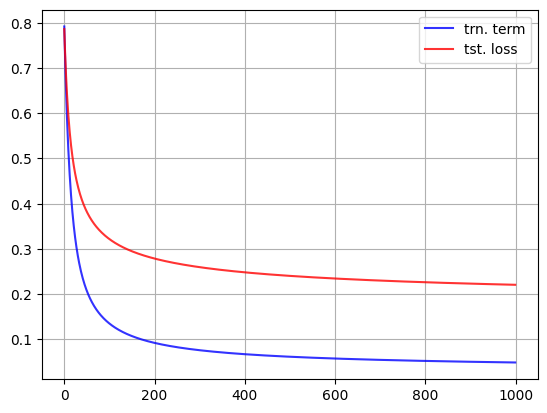

In [13]:
plot_losses(trn_losses, tst_losses)

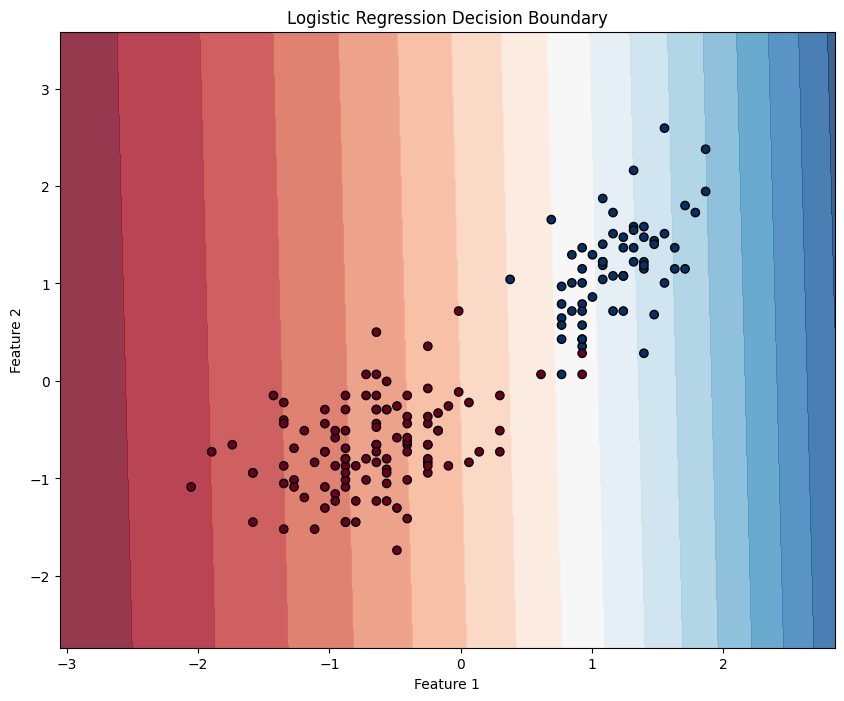

In [14]:
def plot_decision_boundary(X, y, model, X_mean=None, X_std=None, title="Decision Boundary"):
    plt.figure(figsize=(10, 8))
    
    x_min, x_max = X[:, 0].min() - 1, X[:, 0].max() + 1
    y_min, y_max = X[:, 1].min() - 1, X[:, 1].max() + 1
    xx, yy = np.meshgrid(np.arange(x_min, x_max, 0.02),
                         np.arange(y_min, y_max, 0.02))

    grid = np.c_[xx.ravel(), yy.ravel()]
    if X_mean is not None and X_std is not None:
        grid_scaled = (grid - X_mean) / X_std
    probs = model.forward(grid_scaled).reshape(xx.shape)

    plt.contourf(xx, yy, probs, alpha=0.8, levels=20, cmap='RdBu')
    plt.scatter(X[:, 0], X[:, 1], c=y, edgecolors='k', cmap='RdBu')
    plt.xlabel('Feature 1')
    plt.ylabel('Feature 2')
    plt.title(title)
    plt.show()

plot_decision_boundary(X, y, model, X_mean, X_std, "Logistic Regression Decision Boundary")